<a href="https://colab.research.google.com/github/aoxxoa/ccs8---cc19-code/blob/main/InternetUsage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset taken from: https://www.kaggle.com/datasets/jayjoshi37/daily-internet-usage-statistics-by-age-group

# **Step 1: Data Cleaning**

In [ ]:
import pandas as pd

In [ ]:
import kagglehub

path = kagglehub.dataset_download("jayjoshi37/daily-internet-usage-statistics-by-age-group")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'daily-internet-usage-statistics-by-age-group' dataset.
Path to dataset files: /kaggle/input/daily-internet-usage-statistics-by-age-group


In [ ]:
df = pd.read_csv('/kaggle/input/daily-internet-usage-statistics-by-age-group/daily_internet_usage_by_age_group.csv')

In [ ]:
print(df)
print(df.head(10))
print(df.tail(10))

      user_id        date  age age_group  social_media_hours  \
0           1  2024-04-02   15     13-18                 2.2   
1           2  2024-06-07   13     13-18                 1.1   
2           3  2024-04-03   21     19-25                 1.3   
3           4  2024-10-02   35     26-35                 2.5   
4           5  2024-10-05   49     46-60                 0.2   
...       ...         ...  ...       ...                 ...   
2795     2796  2024-11-19   33     26-35                 3.2   
2796     2797  2024-06-24   52     46-60                 2.1   
2797     2798  2024-03-11   21     19-25                 1.2   
2798     2799  2024-12-30   20     19-25                 2.2   
2799     2800  2024-06-26   53     46-60                 1.9   

      work_or_study_hours  entertainment_hours  total_screen_time  \
0                     3.7                  2.4                8.3   
1                     6.9                  2.1               10.1   
2                     5.

In [ ]:
df.describe()

,user_id,age,social_media_hours,work_or_study_hours,entertainment_hours,total_screen_time
count,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000
mean,1400.500000,38.397500,2.117143,4.016107,2.021929,8.155179
std,808.434702,18.436556,1.113908,1.722615,0.876120,2.211885
min,1.000000,13.000000,0.200000,1.000000,0.500000,2.000000
25%,700.750000,22.000000,1.100000,2.500000,1.300000,6.600000
50%,1400.500000,35.000000,2.100000,4.000000,2.000000,8.100000
75%,2100.250000,53.000000,3.100000,5.500000,2.800000,9.700000
max,2800.000000,75.000000,4.000000,7.000000,3.500000,14.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              2800 non-null   int64  
 1   date                 2800 non-null   object 
 2   age                  2800 non-null   int64  
 3   age_group            2800 non-null   object 
 4   social_media_hours   2800 non-null   float64
 5   work_or_study_hours  2800 non-null   float64
 6   entertainment_hours  2800 non-null   float64
 7   total_screen_time    2800 non-null   float64
 8   primary_device       2800 non-null   object 
 9   internet_type        2800 non-null   object 
dtypes: float64(4), int64(2), object(4)
memory usage: 218.9+ KB


In [ ]:
df.shape

(2800, 10)

In [ ]:
df.dtypes

,0
user_id,int64
date,object
age,int64
age_group,object
social_media_hours,float64
work_or_study_hours,float64
entertainment_hours,float64
total_screen_time,float64
primary_device,object
internet_type,object


In [ ]:
print(df.isnull().sum())

user_id                0
date                   0
age                    0
age_group              0
social_media_hours     0
work_or_study_hours    0
entertainment_hours    0
total_screen_time      0
primary_device         0
internet_type          0
dtype: int64


In [ ]:
mediansocial_media_hours = df['social_media_hours'].median()
print("Median: ", mediansocial_media_hours)

Median:  2.1


In [ ]:
medianwork_or_study_hours = df['work_or_study_hours'].median()
print("Median: ", medianwork_or_study_hours)

Median:  4.0


In [ ]:
medianentertainment_hours = df['entertainment_hours'].median()
print("Median: ", medianentertainment_hours)

Median:  2.0


In [ ]:
mediantotal_screen_time = df['total_screen_time'].median()
print("Median: ", mediantotal_screen_time)

Median:  8.1


In [ ]:
modeprimary_device = df['primary_device'].mode()
print("Mode: ", modeprimary_device)

Mode:  0    Tablet
Name: primary_device, dtype: object


In [ ]:
modeinternet_type = df['internet_type'].mode()
print("Mode: ", modeinternet_type)

Mode:  0    WiFi
Name: internet_type, dtype: object


In [ ]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


In [ ]:
print(df.isnull().sum())

user_id                0
date                   0
age                    0
age_group              0
social_media_hours     0
work_or_study_hours    0
entertainment_hours    0
total_screen_time      0
primary_device         0
internet_type          0
dtype: int64


In [ ]:
Q1 = df['social_media_hours'].quantile(0.25)
Q3 = df['social_media_hours'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['social_media_hours'] >= lower_bound) & (df['social_media_hours'] <= upper_bound)]

In [ ]:
Q1 = df['work_or_study_hours'].quantile(0.25)
Q3 = df['work_or_study_hours'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['work_or_study_hours'] >= lower_bound) & (df['work_or_study_hours'] <= upper_bound)]

In [ ]:
Q1 = df['entertainment_hours'].quantile(0.25)
Q3 = df['entertainment_hours'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['entertainment_hours'] >= lower_bound) & (df['entertainment_hours'] <= upper_bound)]

In [ ]:
Q1 = df['total_screen_time'].quantile(0.25)
Q3 = df['total_screen_time'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['total_screen_time'] >= lower_bound) & (df['total_screen_time'] <= upper_bound)]

In [ ]:
import numpy as np
df['social_media_hours'] = np.where((df['social_media_hours'] < lower_bound) | (df['social_media_hours'] > upper_bound), np.nan, df['social_media_hours'])
df['social_media_hours'].fillna(df['social_media_hours'].mean(), inplace=True)

/tmp/ipykernel_18382/2051779117.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['social_media_hours'].fillna(df['social_media_hours'].mean(), inplace=True)


In [ ]:
df['work_or_study_hours'] = np.where((df['work_or_study_hours'] < lower_bound) | (df['work_or_study_hours'] > upper_bound), np.nan, df['work_or_study_hours'])
df['work_or_study_hours'].fillna(df['work_or_study_hours'].mean(), inplace=True)

/tmp/ipykernel_18382/1904378618.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['work_or_study_hours'].fillna(df['work_or_study_hours'].mean(), inplace=True)


In [ ]:
df['entertainment_hours'] = np.where((df['entertainment_hours'] < lower_bound) | (df['entertainment_hours'] > upper_bound), np.nan, df['entertainment_hours'])
df['entertainment_hours'].fillna(df['entertainment_hours'].mean(), inplace=True)

/tmp/ipykernel_18382/953812577.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['entertainment_hours'].fillna(df['entertainment_hours'].mean(), inplace=True)


In [ ]:
df['total_screen_time'] = np.where((df['total_screen_time'] < lower_bound) | (df['total_screen_time'] > upper_bound), np.nan, df['total_screen_time'])
df['total_screen_time'].fillna(df['total_screen_time'].mean(), inplace=True)

/tmp/ipykernel_18382/2726465112.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['total_screen_time'].fillna(df['total_screen_time'].mean(), inplace=True)


# **Step 2: Data Transformation**

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df[['social_media_hours', 'work_or_study_hours', 'entertainment_hours', 'total_screen_time']] = scaler.fit_transform(df[['social_media_hours', 'work_or_study_hours', 'entertainment_hours', 'total_screen_time']])

df.head()

,user_id,date,age,age_group,social_media_hours,work_or_study_hours,entertainment_hours,total_screen_time,primary_device,internet_type
0,1,2024-04-02,15,13-18,0.100000,0.34,0.266667,0.525000,Mobile,WiFi
1,2,2024-06-07,13,13-18,0.497415,0.98,0.066667,0.675000,Tablet,WiFi
2,3,2024-04-03,21,19-25,0.497415,0.74,0.495554,0.550000,Tablet,WiFi
3,4,2024-10-02,35,26-35,0.250000,0.60,0.000000,0.625000,Mobile,WiFi
4,5,2024-10-05,49,46-60,0.497415,0.86,0.533333,0.608333,Laptop,WiFi


In [ ]:
df = pd.get_dummies(df, columns=['age_group', 'primary_device', 'internet_type'], drop_first=True)

df.head()

,user_id,date,age,social_media_hours,work_or_study_hours,entertainment_hours,total_screen_time,age_group_19-25,age_group_26-35,age_group_36-45,age_group_46-60,age_group_60+,primary_device_Mobile,primary_device_Tablet,internet_type_WiFi
0,1,2024-04-02,15,0.100000,0.34,0.266667,0.525000,False,False,False,False,False,True,False,True
1,2,2024-06-07,13,0.497415,0.98,0.066667,0.675000,False,False,False,False,False,False,True,True
2,3,2024-04-03,21,0.497415,0.74,0.495554,0.550000,True,False,False,False,False,False,True,True
3,4,2024-10-02,35,0.250000,0.60,0.000000,0.625000,False,True,False,False,False,True,False,True
4,5,2024-10-05,49,0.497415,0.86,0.533333,0.608333,False,False,False,True,False,False,False,True


In [ ]:
df['leisure_hours'] = df['social_media_hours'] + df['entertainment_hours']

df.head()

,user_id,date,age,social_media_hours,work_or_study_hours,entertainment_hours,total_screen_time,age_group_19-25,age_group_26-35,age_group_36-45,age_group_46-60,age_group_60+,primary_device_Mobile,primary_device_Tablet,internet_type_WiFi,leisure_hours
0,1,2024-04-02,15,0.100000,0.34,0.266667,0.525000,False,False,False,False,False,True,False,True,0.366667
1,2,2024-06-07,13,0.497415,0.98,0.066667,0.675000,False,False,False,False,False,False,True,True,0.564082
2,3,2024-04-03,21,0.497415,0.74,0.495554,0.550000,True,False,False,False,False,False,True,True,0.992969
3,4,2024-10-02,35,0.250000,0.60,0.000000,0.625000,False,True,False,False,False,True,False,True,0.250000
4,5,2024-10-05,49,0.497415,0.86,0.533333,0.608333,False,False,False,True,False,False,False,True,1.030748


# **Step 3: Data Reduction Methods**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.feature_selection import RFE
from sklearn.linear_model import Lasso, LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/kaggle/input/daily-internet-usage-statistics-by-age-group/daily_internet_usage_by_age_group.csv')

In [ ]:
le_age = LabelEncoder()
le_device = LabelEncoder()
le_internet = LabelEncoder()

df['age_group_encoded'] = le_age.fit_transform(df['age_group'])
df['primary_device_encoded'] = le_device.fit_transform(df['primary_device'])
df['internet_type_encoded'] = le_internet.fit_transform(df['internet_type'])

In [ ]:
feature_cols = ['social_media_hours', 'work_or_study_hours', 'entertainment_hours',
                'age_group_encoded', 'primary_device_encoded', 'internet_type_encoded']
target_col = 'total_screen_time'

X = df[feature_cols]
y = df[target_col]

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### 3.1 Dimensionality Reduction

In [ ]:
# Apply Principal Component Analysis (PCA)
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

In [ ]:
# Check explained variance ratio to identify highly correlated features
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

print("PCA Results:")
print(f"Number of original features: {X.shape[1]}")
print(f"Explained variance ratio for each component: {explained_variance_ratio}")
print(f"Cumulative explained variance: {cumulative_variance}")

PCA Results:
Number of original features: 6
Explained variance ratio for each component: [0.17588283 0.17290227 0.16755444 0.16669271 0.16110167 0.15586607]
Cumulative explained variance: [0.17588283 0.34878511 0.51633954 0.68303225 0.84413393 1.        ]


In [ ]:
# Determine number of components to retain (e.g., 95% variance)
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"\nNumber of components needed to explain 95% variance: {n_components_95}")



Number of components needed to explain 95% variance: 6


In [ ]:
# Reduce features using PCA
pca_reduced = PCA(n_components=n_components_95)
X_pca_reduced = pca_reduced.fit_transform(X_scaled)
print(f"Reduced feature set shape: {X_pca_reduced.shape}")

Reduced feature set shape: (2800, 6)


In [ ]:
# t-SNE for visualizing high-dimensional data
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

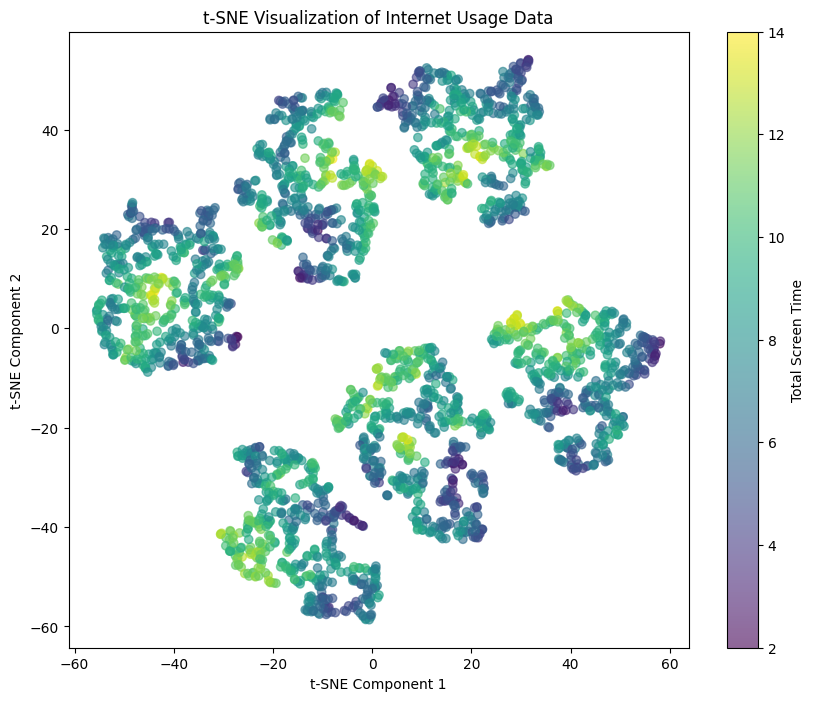

In [ ]:
# Visualize t-SNE results
plt.figure(figsize=(10, 8))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='viridis', alpha=0.6)
plt.colorbar(label='Total Screen Time')
plt.title('t-SNE Visualization of Internet Usage Data')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.savefig('tsne_visualization.png')
plt.show()

### 3.2 Feature Selection

In [ ]:
# Calculate correlation matrix to identify features strongly related to target
correlation_matrix = df[feature_cols + [target_col]].corr()
target_correlations = correlation_matrix[target_col].drop(target_col).sort_values(ascending=False)

print("\nFilter Method - Correlation Analysis:")
print("Features most strongly correlated with total screen time:")
print(target_correlations)


Filter Method - Correlation Analysis:
Features most strongly correlated with total screen time:
work_or_study_hours       0.776828
social_media_hours        0.485475
entertainment_hours       0.380011
primary_device_encoded    0.024992
internet_type_encoded     0.014893
age_group_encoded        -0.011372
Name: total_screen_time, dtype: float64


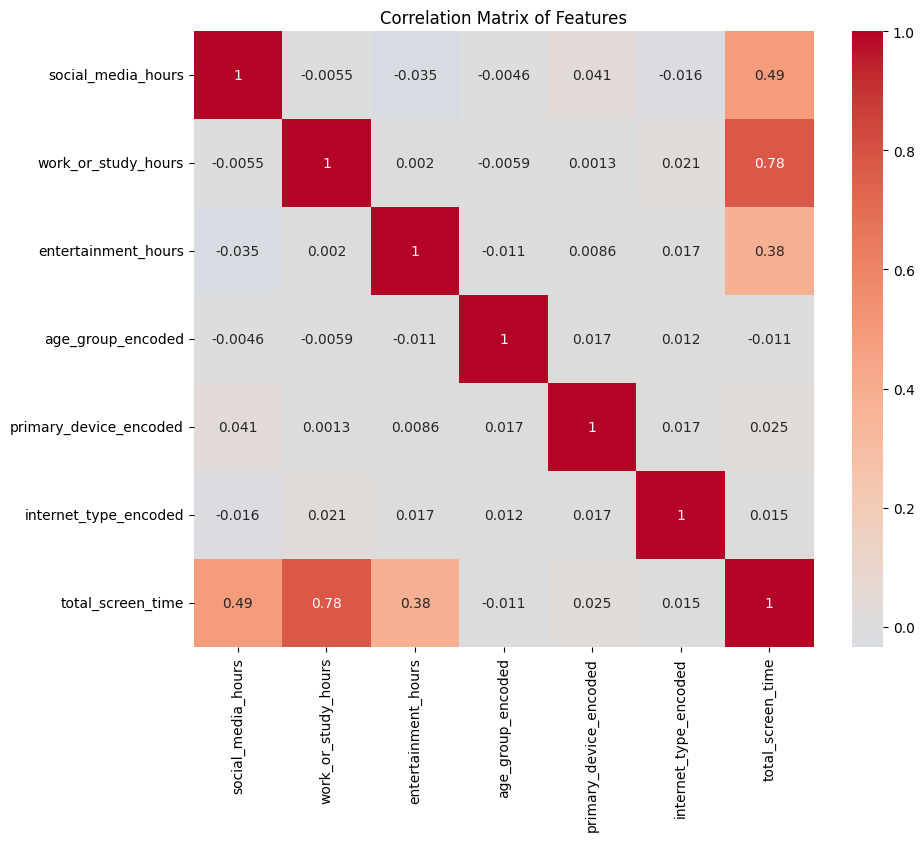

In [ ]:
# Visualize correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Features')
plt.savefig('correlation_heatmap.png')
plt.show()

In [ ]:
# Apply RFE with Linear Regression
estimator = LinearRegression()
rfe = RFE(estimator, n_features_to_select=3, step=1)
rfe.fit(X_scaled, y)

print("\nWrapper Method - Recursive Feature Elimination (RFE):")
print(f"Selected features: {[feature_cols[i] for i in range(len(rfe.support_)) if rfe.support_[i]]}")
print(f"Feature rankings: {dict(zip(feature_cols, rfe.ranking_))}")


Wrapper Method - Recursive Feature Elimination (RFE):
Selected features: ['social_media_hours', 'work_or_study_hours', 'entertainment_hours']
Feature rankings: {'social_media_hours': np.int64(1), 'work_or_study_hours': np.int64(1), 'entertainment_hours': np.int64(1), 'age_group_encoded': np.int64(3), 'primary_device_encoded': np.int64(2), 'internet_type_encoded': np.int64(4)}


In [ ]:
# Apply Lasso Regression for automatic feature selection
lasso = Lasso(alpha=0.01, random_state=42)
lasso.fit(X_scaled, y)

Lasso(alpha=0.01, random_state=42)

In [ ]:
# Identify features with non-zero coefficients
lasso_selected = [feature_cols[i] for i in range(len(lasso.coef_)) if lasso.coef_[i] != 0]

print("\nEmbedded Method - Lasso Regression:")
print(f"Features selected by Lasso: {lasso_selected}")
print(f"Coefficients: {dict(zip(feature_cols, lasso.coef_))}")


Embedded Method - Lasso Regression:
Features selected by Lasso: ['social_media_hours', 'work_or_study_hours', 'entertainment_hours']
Coefficients: {'social_media_hours': np.float64(1.1032925023288502), 'work_or_study_hours': np.float64(1.7122712602503212), 'entertainment_hours': np.float64(0.8656187086701187), 'age_group_encoded': np.float64(-0.0), 'primary_device_encoded': np.float64(0.0), 'internet_type_encoded': np.float64(0.0)}
